In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import noisereduce as nr
def plot_waveform(y, sr):
    t = np.linspace(0, len(y)/sr,num=len(y))
    plt.figure(figsize=(15,4))
    plt.plot(t,y)
    plt.title("Waveform")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.show()

c:\Users\ernun\VoicePathologyClassification\VoicePathologyClassification\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
voice003, sr003 = librosa.load("C:\\Users\\ernun\\OneDrive\\Desktop\\VoicePathologyClassification\\voice003.wav",sr=None)
voice004, sr004 = librosa.load("C:\\Users\\ernun\\OneDrive\\Desktop\\VoicePathologyClassification\\voice004.wav",sr=None)
voice005, sr005 = librosa.load("C:\\Users\\ernun\\OneDrive\\Desktop\\VoicePathologyClassification\\voice005.wav",sr=None)

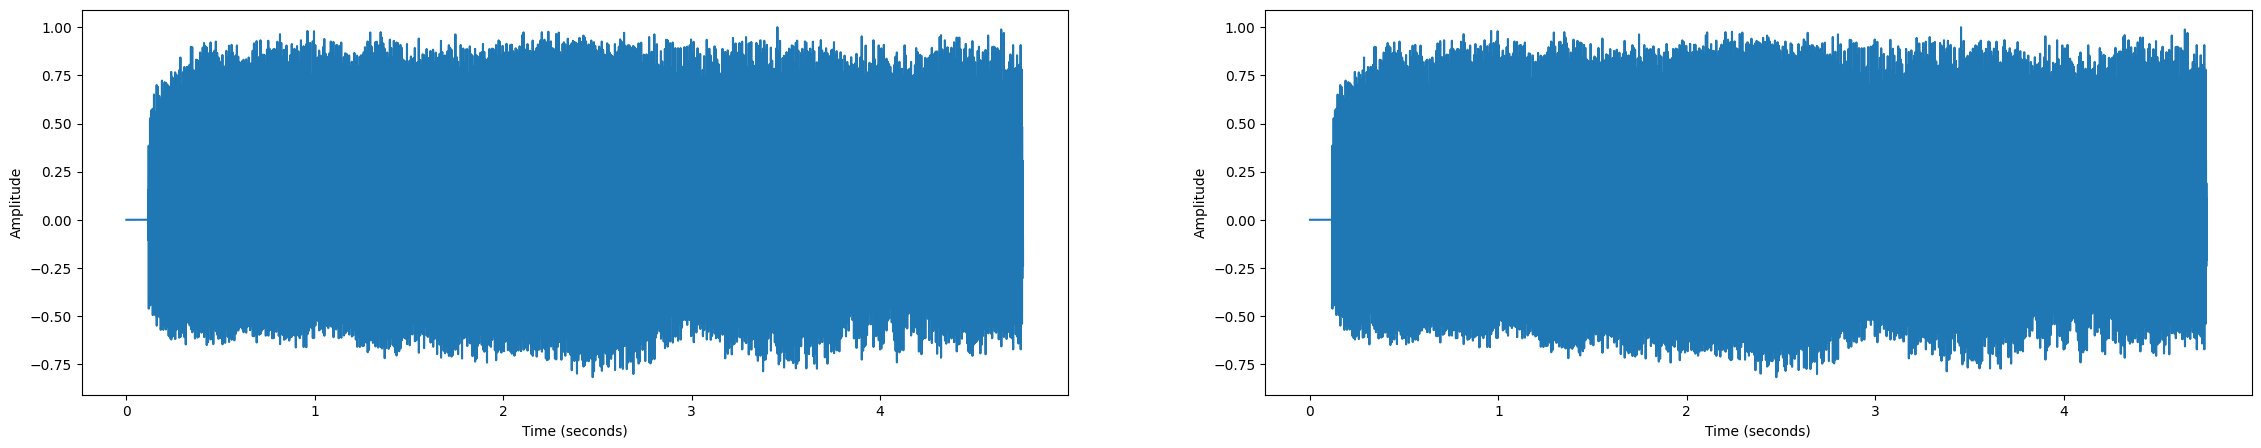

In [4]:
# before trim 003
t_003 = np.linspace(0, len(voice003)/sr003,num=len(voice003))

# after trim 003
voice003_trim, index003 = librosa.effects.trim(voice003)
t_003_trim = np.linspace(0, len(voice003_trim)/sr003,num=len(voice003_trim))

plt.figure(figsize=(28,5))
plt.subplot(1,2,1)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot(t_003,voice003)

plt.subplot(1,2,2)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot(t_003_trim,voice003_trim)
plt.show()

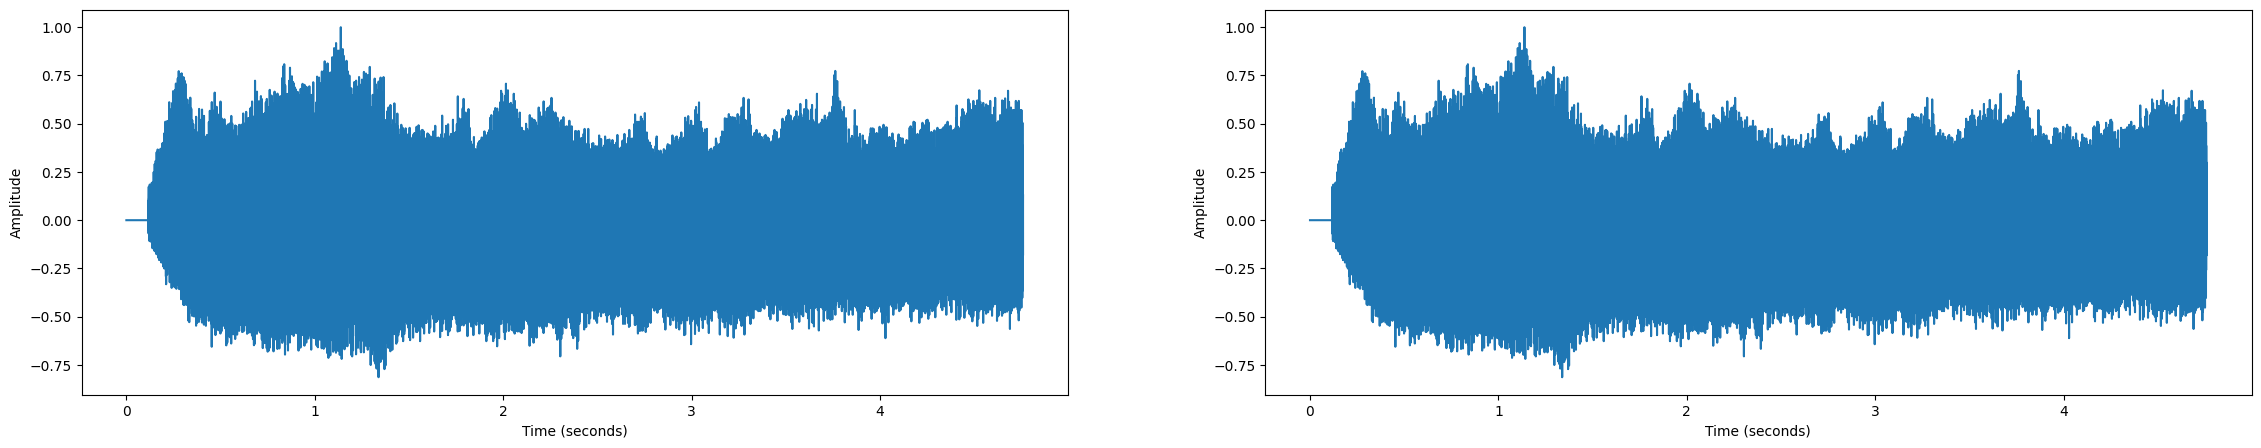

In [5]:
# before trim 004
t_004 = np.linspace(0, len(voice004)/sr004,num=len(voice004))

# after trim 004
voice004_trim, index003 = librosa.effects.trim(voice004)
t_004_trim = np.linspace(0, len(voice004_trim)/sr004,num=len(voice004_trim))

plt.figure(figsize=(28,5))
plt.subplot(1,2,1)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot(t_004,voice004)

plt.subplot(1,2,2)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot(t_004_trim,voice004_trim)
plt.show()

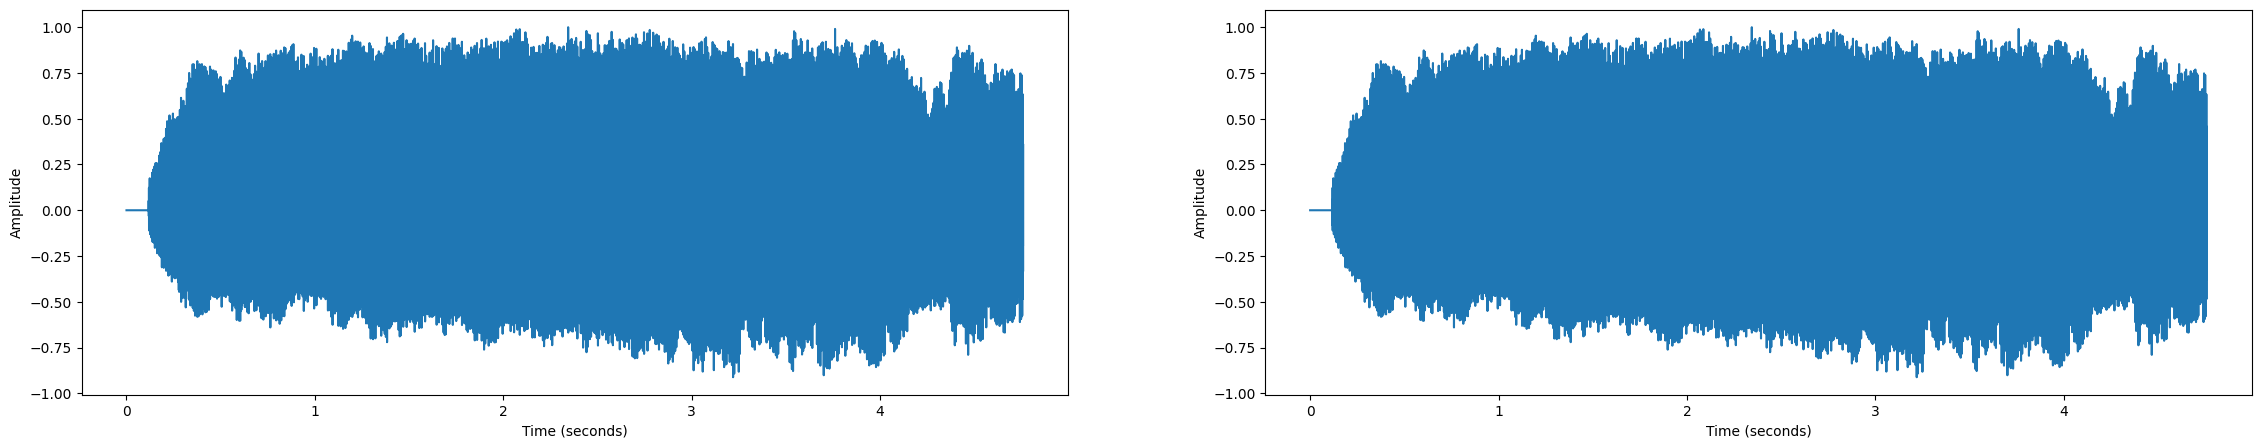

In [6]:
# before trim 005
t_005 = np.linspace(0, len(voice005)/sr005,num=len(voice005))

# after trim 005
voice005_trim, index005 = librosa.effects.trim(voice005)
t_005_trim = np.linspace(0, len(voice005_trim)/sr005,num=len(voice005_trim))

plt.figure(figsize=(28,5))
plt.subplot(1,2,1)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot(t_005,voice005)

plt.subplot(1,2,2)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot(t_005_trim,voice005_trim)
plt.show()

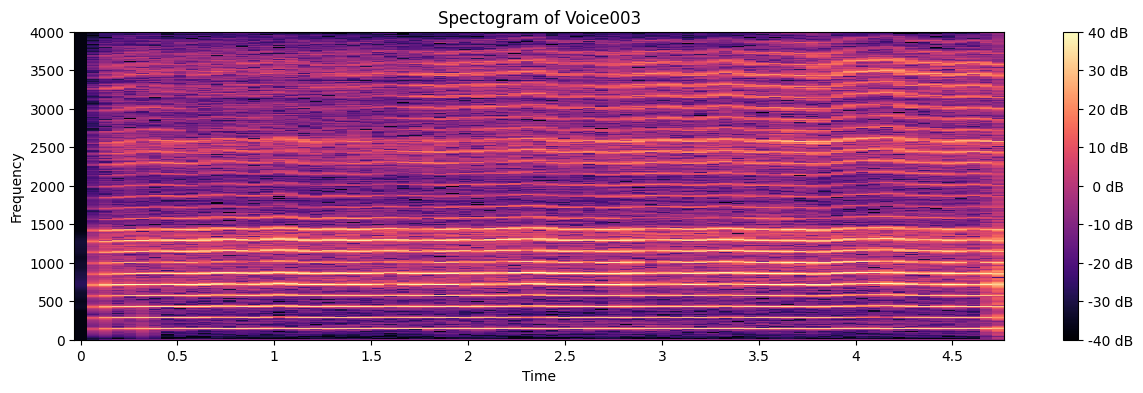

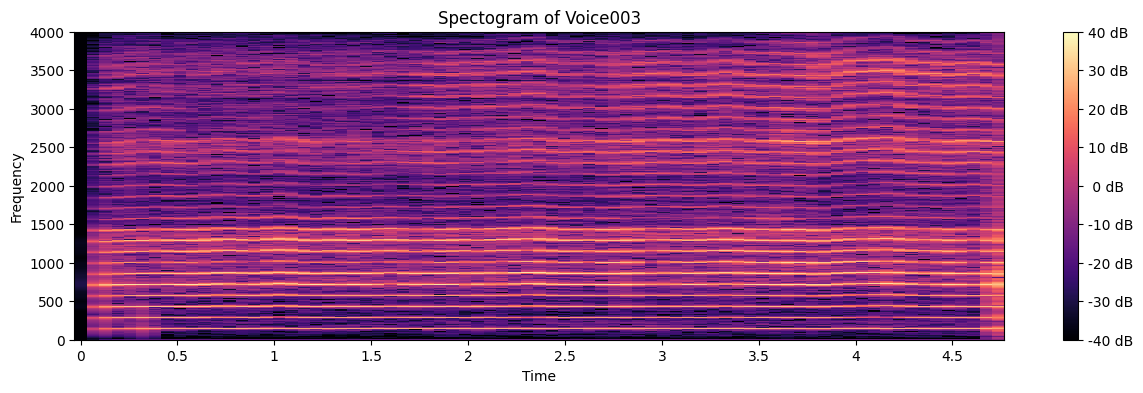

In [7]:
def plot_spectogram(y,sr):
    y_stft = librosa.stft(y)
    y_dB = librosa.amplitude_to_db(np.abs(y_stft))

    plt.figure(figsize=(15,4))
    librosa.display.specshow(y_dB,sr=sr,x_axis="time",y_axis="hz",cmap="magma",vmin=-40,vmax=40)
    plt.colorbar(format="%2.0f dB")
    plt.title("Spectogram of Voice003")
    plt.xlabel("Time")
    plt.ylabel("Frequency")

plot_spectogram(voice003,sr003)

voice003_nr = nr.reduce_noise(voice003,sr=sr003,prop_decrease=0.5)
plot_spectogram(voice003_nr,sr003)


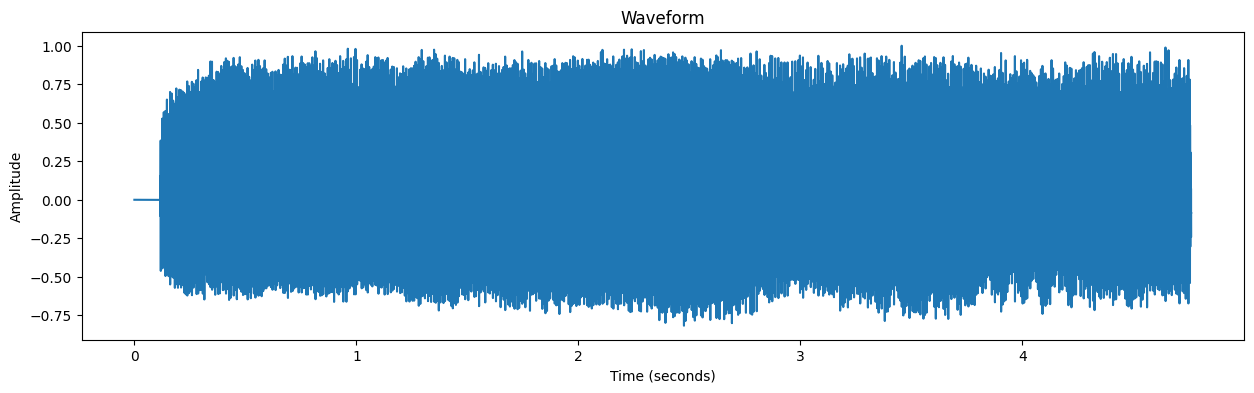

In [8]:
peak_voice002 = np.max(voice003)
normalized_003 = voice003 / peak_voice002
plot_waveform(normalized_003, sr003)

def normalize(audio_arr):
    peak = np.max(audio_arr)
    return (audio_arr / peak)

def resample16kHz(audio_arr, orig_sampling_rate):
    return librosa.resample(audio_arr, orig_sampling_rate, 16000)
